# BOCPD Testing Notebook

Quick smoke test of the Fast_BOCPD implementation with synthetic data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fast_bocpd import BOCPD, ConstantHazard, GaussianNIG

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# Quick sanity check - run a simple example
test_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
test_hazard = ConstantHazard(lambda_=100)
test_bocpd = BOCPD(test_model, test_hazard, max_run_length=50)

# Generate simple data
test_data = [0.1, 0.2, 0.15, 5.0, 5.1, 4.9]  # Clear jump at position 3
test_probs = []

for x in test_data:
    posterior_r, cp_prob = test_bocpd.update(x)
    test_probs.append(cp_prob)
    print(f"x={x:.2f}, cp_prob={cp_prob:.6f}, sum(posterior_r)={np.sum(posterior_r):.6f}")

print(f"\nCP probs: {test_probs}")

x=0.10, cp_prob=0.010000, sum(posterior_r)=1.000000
x=0.20, cp_prob=0.006854, sum(posterior_r)=1.000000
x=0.15, cp_prob=0.005487, sum(posterior_r)=1.000000
x=5.00, cp_prob=0.188768, sum(posterior_r)=1.000000
x=5.10, cp_prob=0.003517, sum(posterior_r)=1.000000
x=4.90, cp_prob=0.001671, sum(posterior_r)=1.000000

CP probs: [0.009999999999999995, 0.006853623739474838, 0.005486582353185705, 0.18876801592191353, 0.0035166617962794204, 0.0016714388049346904]


## Test 1: Constant Signal (No Changepoints)

Should show low changepoint probabilities throughout.

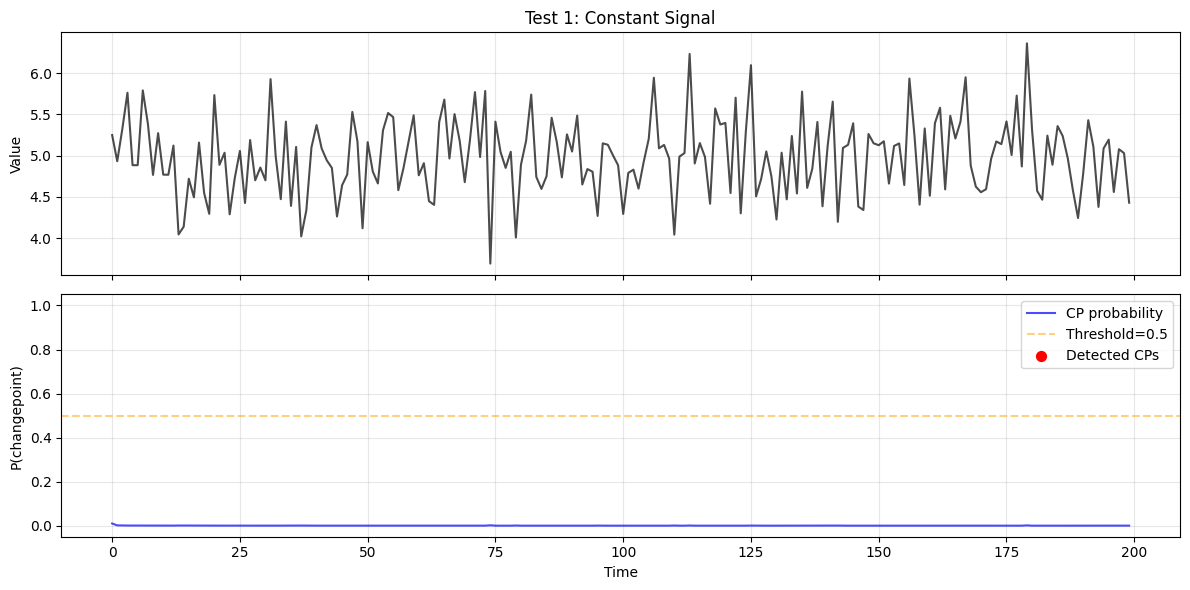

Mean CP probability: 0.0004
Max CP probability: 0.0100
Number of detected CPs (threshold=0.5): 0


In [3]:
# Generate constant signal with noise
n_points = 200
data = np.random.randn(n_points) * 0.5 + 5.0

# Initialize BOCPD
obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=100)
bocpd = BOCPD(obs_model, hazard, max_run_length=200)

# Run BOCPD
cp_probs = []
for x in data:
    posterior_r, cp_prob = bocpd.update(x)
    cp_probs.append(cp_prob)

# Detect changepoints with threshold
threshold = 0.5
detected_cps = [i for i, p in enumerate(cp_probs) if p > threshold]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(data, 'k-', alpha=0.7)
for cp in detected_cps:
    ax1.axvline(cp, color='r', linestyle=':', alpha=0.3)
ax1.set_ylabel('Value')
ax1.set_title('Test 1: Constant Signal')
ax1.grid(True, alpha=0.3)

ax2.plot(cp_probs, 'b-', alpha=0.7, label='CP probability')
ax2.axhline(threshold, color='orange', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
ax2.scatter(detected_cps, [cp_probs[i] for i in detected_cps], 
           color='r', s=50, zorder=5, label='Detected CPs')
ax2.set_ylabel('P(changepoint)')
ax2.set_xlabel('Time')
ax2.set_ylim([-0.05, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean CP probability: {np.mean(cp_probs):.4f}")
print(f"Max CP probability: {np.max(cp_probs):.4f}")
print(f"Number of detected CPs (threshold={threshold}): {len(detected_cps)}")

## Test 2: Single Step Change

Should detect a clear changepoint at t=100.

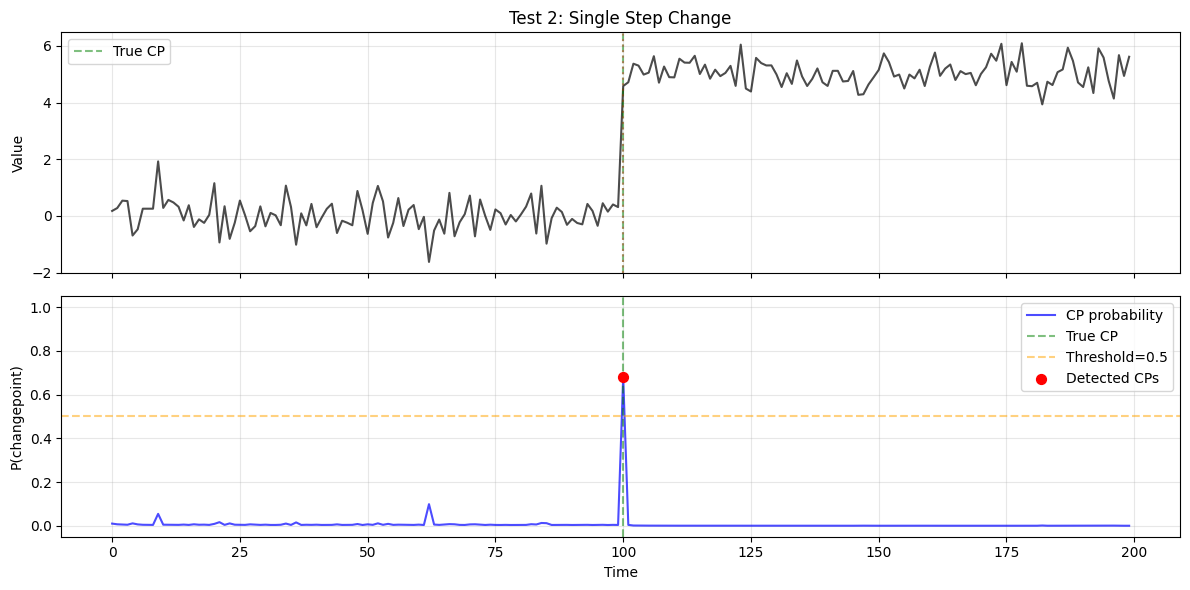

CP probability at t=100: 0.6790
CP probability at t=101: 0.0042
Detected CPs: [100]


In [4]:
# Generate data with step change
n_points = 200
data = np.concatenate([
    np.random.randn(100) * 0.5 + 0.0,   # First segment: mean=0
    np.random.randn(100) * 0.5 + 5.0    # Second segment: mean=5
])

# Initialize BOCPD
obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=100)
bocpd = BOCPD(obs_model, hazard, max_run_length=200)

# Run BOCPD
cp_probs = []
for x in data:
    posterior_r, cp_prob = bocpd.update(x)
    cp_probs.append(cp_prob)

# Detect changepoints with threshold
threshold = 0.5
detected_cps = [i for i, p in enumerate(cp_probs) if p > threshold]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(data, 'k-', alpha=0.7)
ax1.axvline(100, color='g', linestyle='--', alpha=0.5, label='True CP')
for cp in detected_cps:
    ax1.axvline(cp, color='r', linestyle=':', alpha=0.3)
ax1.set_ylabel('Value')
ax1.set_title('Test 2: Single Step Change')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cp_probs, 'b-', alpha=0.7, label='CP probability')
ax2.axvline(100, color='g', linestyle='--', alpha=0.5, label='True CP')
ax2.axhline(threshold, color='orange', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
ax2.scatter(detected_cps, [cp_probs[i] for i in detected_cps], 
           color='r', s=50, zorder=5, label='Detected CPs')
ax2.set_ylabel('P(changepoint)')
ax2.set_xlabel('Time')
ax2.set_ylim([-0.05, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"CP probability at t=100: {cp_probs[100]:.4f}")
print(f"CP probability at t=101: {cp_probs[101]:.4f}")
print(f"Detected CPs: {detected_cps}")

## Test 3: Multiple Changepoints

Should detect changepoints at t=50, 100, 150.

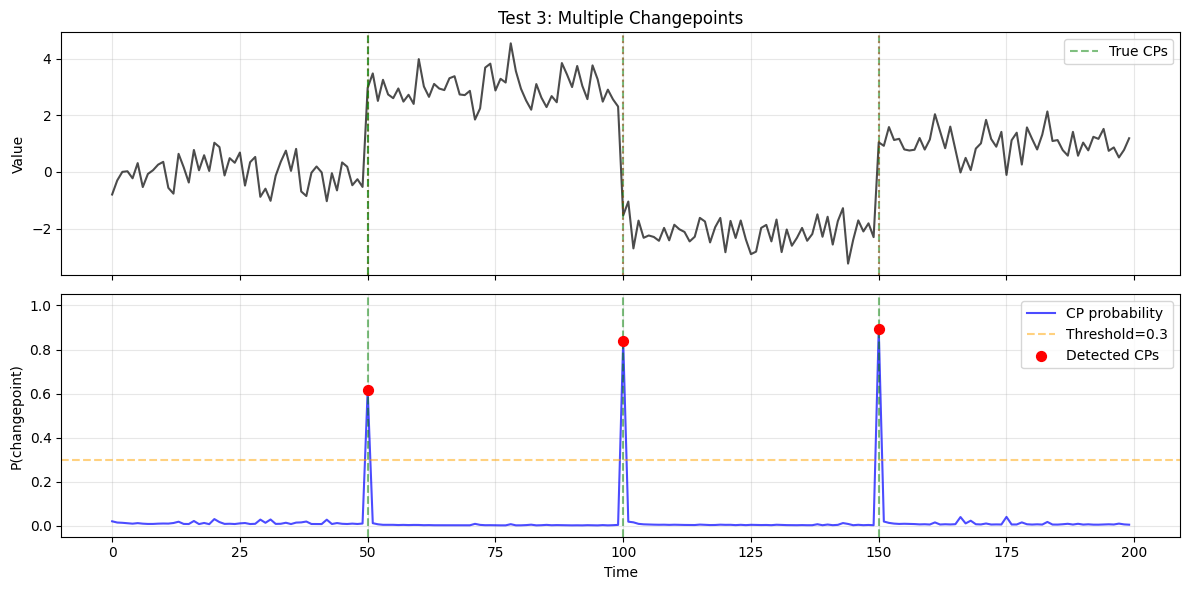

CP probability at t=50: 0.6147
CP probability at t=100: 0.8376
CP probability at t=150: 0.8913
Detected CPs: [50, 100, 150]


In [5]:
# Generate data with multiple changepoints
n_points = 200
data = np.concatenate([
    np.random.randn(50) * 0.5 + 0.0,
    np.random.randn(50) * 0.5 + 3.0,
    np.random.randn(50) * 0.5 - 2.0,
    np.random.randn(50) * 0.5 + 1.0
])

# Initialize BOCPD
obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
bocpd = BOCPD(obs_model, hazard, max_run_length=200)

# Run BOCPD
cp_probs = []
for x in data:
    posterior_r, cp_prob = bocpd.update(x)
    cp_probs.append(cp_prob)

# Detect changepoints with threshold
threshold = 0.3  # Lower threshold for multiple CPs
detected_cps = [i for i, p in enumerate(cp_probs) if p > threshold]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.plot(data, 'k-', alpha=0.7)
for cp_loc in [50, 100, 150]:
    ax1.axvline(cp_loc, color='g', linestyle='--', alpha=0.5)
for cp in detected_cps:
    ax1.axvline(cp, color='r', linestyle=':', alpha=0.3)
ax1.axvline(50, color='g', linestyle='--', alpha=0.5, label='True CPs')
ax1.set_ylabel('Value')
ax1.set_title('Test 3: Multiple Changepoints')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(cp_probs, 'b-', alpha=0.7, label='CP probability')
for cp_loc in [50, 100, 150]:
    ax2.axvline(cp_loc, color='g', linestyle='--', alpha=0.5)
ax2.axhline(threshold, color='orange', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
ax2.scatter(detected_cps, [cp_probs[i] for i in detected_cps], 
           color='r', s=50, zorder=5, label='Detected CPs')
ax2.set_ylabel('P(changepoint)')
ax2.set_xlabel('Time')
ax2.set_ylim([-0.05, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"CP probability at t=50: {cp_probs[50]:.4f}")
print(f"CP probability at t=100: {cp_probs[100]:.4f}")
print(f"CP probability at t=150: {cp_probs[150]:.4f}")
print(f"Detected CPs: {detected_cps}")

## Test 4: Run Length Distribution Visualization

Visualize the full posterior distribution over run lengths (the classic BOCPD heatmap).

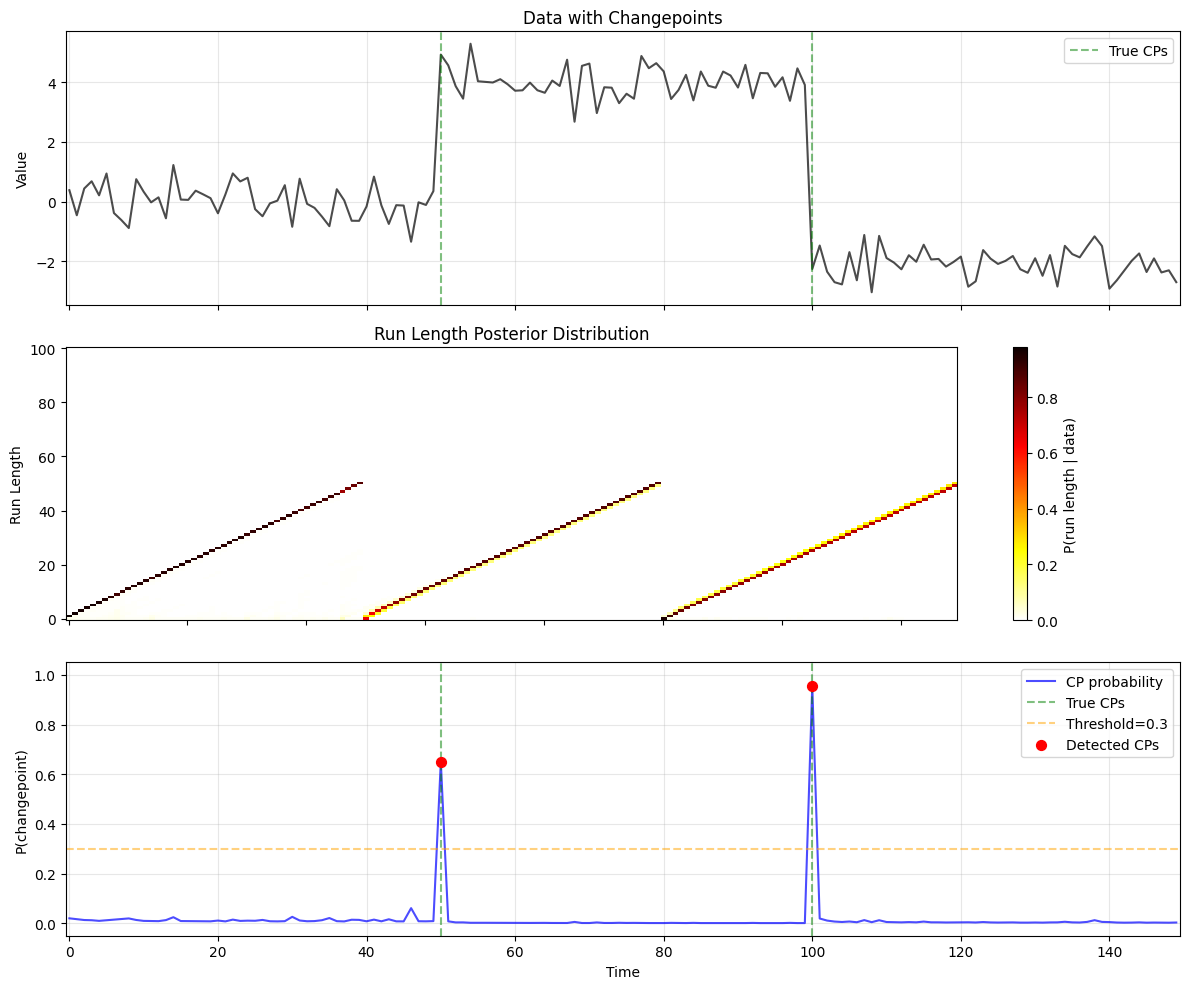

Detected CPs: [50, 100]


In [6]:
# Generate data with changepoints
n_points = 150
data = np.concatenate([
    np.random.randn(50) * 0.5 + 0.0,
    np.random.randn(50) * 0.5 + 4.0,
    np.random.randn(50) * 0.5 - 2.0
])

# Initialize BOCPD
obs_model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)
max_rl = 100
bocpd = BOCPD(obs_model, hazard, max_run_length=max_rl)

# Run BOCPD and collect run length posteriors
run_length_matrix = np.zeros((n_points, max_rl + 1))
cp_probs = []

for t, x in enumerate(data):
    posterior_r, cp_prob = bocpd.update(x)
    run_length_matrix[t, :] = posterior_r
    cp_probs.append(cp_prob)

# Plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Data
ax1.plot(data, 'k-', alpha=0.7)
ax1.axvline(50, color='g', linestyle='--', alpha=0.5, label='True CPs')
ax1.axvline(100, color='g', linestyle='--', alpha=0.5)
ax1.set_ylabel('Value')
ax1.set_title('Data with Changepoints')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Run length distribution heatmap
im = ax2.imshow(run_length_matrix.T, aspect='auto', cmap='hot_r', 
                interpolation='nearest', origin='lower')
ax2.set_ylabel('Run Length')
ax2.set_title('Run Length Posterior Distribution')
plt.colorbar(im, ax=ax2, label='P(run length | data)')

# Changepoint probabilities
threshold = 0.3
detected_cps = [i for i, p in enumerate(cp_probs) if p > threshold]

ax3.plot(cp_probs, 'b-', alpha=0.7, label='CP probability')
ax3.axvline(50, color='g', linestyle='--', alpha=0.5, label='True CPs')
ax3.axvline(100, color='g', linestyle='--', alpha=0.5)
ax3.axhline(threshold, color='orange', linestyle='--', alpha=0.5, label=f'Threshold={threshold}')
ax3.scatter(detected_cps, [cp_probs[i] for i in detected_cps], 
           color='r', s=50, zorder=5, label='Detected CPs')
ax3.set_ylabel('P(changepoint)')
ax3.set_xlabel('Time')
ax3.set_ylim([-0.05, 1.05])
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Detected CPs: {detected_cps}")